# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [2]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [3]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [4]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.
class DNNRegressor(nn.Module):
    def __init__(self, in_dim=6, hidden_dim1=16, hidden_dim2=8, dropout_p=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim1),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim1),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim1, hidden_dim2),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim2),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim2, 4)           # <-- output (linear for regression)
        )

    def forward(self, x):
        return self.net(x)


In [5]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
model = DNNRegressor(in_dim=X_train_s1.shape[1], hidden_dim1=16, hidden_dim2=8, dropout_p=DROPOUT_P).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)  # <-- L2


In [ ]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader=train_loader_1, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep:3d} | train MSE (scaled y): {total / len(loader.dataset):.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# TODO: Train the model
train_part1(model)

Epoch   1 | train MSE (scaled y): 0.766126
Epoch 500 | train MSE (scaled y): 0.103058


In [ ]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8921    0.7753    0.8296      2377
           C     0.9919    0.9174    0.9532      2263
           B     0.9458    0.9653    0.9555      3057
           A     0.9778    0.9800    0.9789      3144

   micro avg     0.9541    0.9179    0.9356     10841
   macro avg     0.9519    0.9095    0.9293     10841
weighted avg     0.9529    0.9179    0.9342     10841
 samples avg     0.6606    0.6486    0.6488     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2902  223]
 [ 534 1843]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3222   17]
 [ 187 2076]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2276  169]
 [ 106 2951]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2288   70]
 [  63 3081]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8916    0.7664    0.8243      1019
           C     0.9856    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _

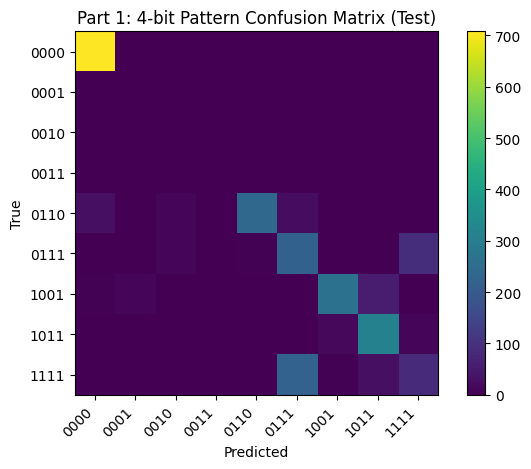

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 28   0  11   0 238  24   0   0   0]
 [  0   0  11   0   4 220   0   0  94]
 [  4  11   0   0   0   0 268  56   0]
 [  0   0   0   1   0   0  14 312  13]
 [  0   0   0   0   0 222   4  29  85]]


In [ ]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [ ]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [ ]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, in_dim=6, hidden_dim1=16, hidden_dim2=8, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim1),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim1),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(p_drop),             # <-- dropout regularization

            nn.Linear(hidden_dim1, hidden_dim2),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim2),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(p_drop),             # <-- dropout regularization
            nn.Linear(hidden_dim2, out_dim) 
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
model = DNN_MultiLabel4(in_dim=X_train_s1.shape[1], hidden_dim1=16, hidden_dim2=8, out_dim=OUT_DIM, p_drop=DROPOUT_P).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)  # <-- L2

In [ ]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep:3d} | average loss: {total / len(loader.dataset):.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

# TODO: Train the model
train_part2(model, train_loader_2)

Epoch   1 | average loss: 0.708954
Epoch 500 | average loss: 0.218352
Epoch 1000 | average loss: 0.200426


In [ ]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8232    0.8599    0.8412      2377
           C     1.0000    0.9116    0.9538      2263
           B     0.9975    0.9284    0.9617      3057
           A     0.9997    0.9784    0.9889      3144

   micro avg     0.9573    0.9244    0.9405     10841
   macro avg     0.9551    0.9196    0.9364     10841
weighted avg     0.9604    0.9244    0.9415     10841
 samples avg     0.6660    0.6522    0.6543     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2686  439]
 [ 333 2044]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3239    0]
 [ 200 2063]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2438    7]
 [ 219 2838]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2357    1]
 [  68 3076]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8287    0.8499    0.8391      1019
           C     1.0000    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _

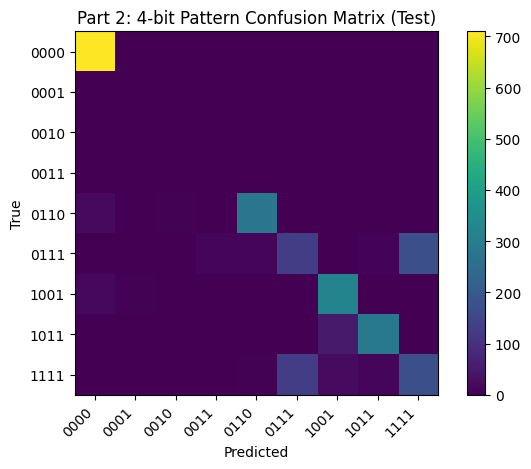

[[710   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 18   0   4   0 279   0   0   0   0]
 [  0   0   0  12  10 128   0   7 172]
 [ 14   4   0   0   0   0 321   0   0]
 [  0   1   0   0   0   0  51 288   0]
 [  0   0   0   0   5 129  22  11 173]]


In [ ]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [ ]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [ ]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, H1),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(H1),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(DROPOUT_P),             # <-- dropout regularization

            nn.Linear(H1, H2),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(H2),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(DROPOUT_P),             # <-- dropout regularization
            nn.Linear(H2, num_classes) 
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
model = DNN_MultiClass6(input_dim=X_train_s1.shape[1]).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # <-- L2

In [ ]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep:3d} | average loss: {total / len(loader.dataset):.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

# TODO: Train the model
train_part3(model, loader=train_loader_3)


Epoch   1 | average loss: 1.851715
Epoch 500 | average loss: 0.595701
Epoch 1000 | average loss: 0.604776



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9490    1.0000    0.9738      1655
          LG     0.8760    0.9481    0.9106       790
          LL     0.9001    0.9360    0.9177       703
         LLG     0.8824    0.9169    0.8993       794
         LLL     0.5409    0.5346    0.5377       767
        LLLG     0.5059    0.3758    0.4313       793

    accuracy                         0.8175      5502
   macro avg     0.7757    0.7852    0.7784      5502
weighted avg     0.8019    0.8175    0.8078      5502



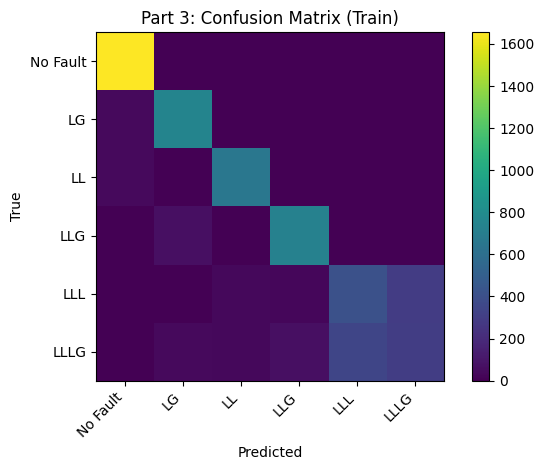


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9454    1.0000    0.9719       710
          LG     0.8815    0.9440    0.9117       339
          LL     0.9065    0.9336    0.9198       301
         LLG     0.8997    0.9235    0.9115       340
         LLL     0.5195    0.5258    0.5227       329
        LLLG     0.4862    0.3618    0.4148       340

    accuracy                         0.8143      2359
   macro avg     0.7731    0.7814    0.7754      2359
weighted avg     0.7991    0.8143    0.8050      2359



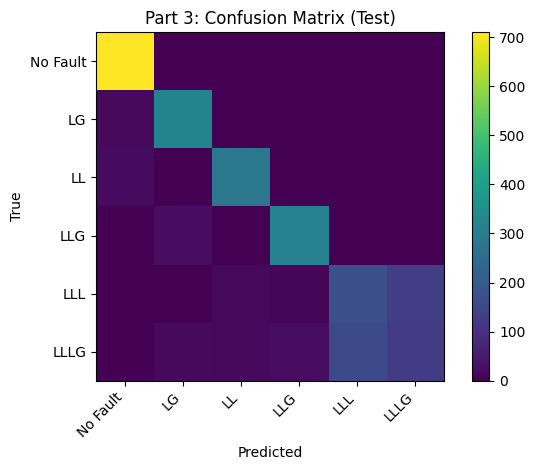

In [ ]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: Parts 1 and 2, regression-style and multi-label, have near identical confusion matrices and test metrics. They achieved high individual bit F1-scores with A, B, and C scoring around 0.95 and G scoring around 0.84. They also had an outstanding micro-average-F1 scores of around 0.94, indicating great generalization. On the other hand, Part 3 had a significant drop off in accuracy for both training and test data, with a micro-average F1 score of about 0.78 and fault types like LLL and LLLG having inidividual F1 scores of ~ 0.5. This ensures that the formulation of parts 1 & 2 are the best for this dataset. I believe that this is because parts 1 and 2 predict each fault bit independently, allowing the model to learn patterns in combinations naturally, as well as learning the patterns of each bit independently (on vs off). Part 3 forces the model to predict one of 6 types, creating sharp boundaries between closely related faults like LLL and LLLG, which limit the model's capacity for accurate generalization. 

- Q2: Yes, the models often outputted fault patterns that were not defined as valid/possible in the introduction. This suggests that bit-based approaches do not explicitly restrict the domain of possible outputs. Essentially, these approaches do not limit the model's predictions to the only 6 possible fault patterns, so valid fault patterns are not always guaranteed. 

- Q3: For bits, all were relatively easy to predict (~ 0.95 F1-score) except G which had an average F1 score of ~ 0.84. The confusion matrices reflect a large number of false negatives for G compared to other bits. A plausible reason for this could be the fact that (G)round may not have a weight significant enough to help distinguish signals with or with out it. Therefore, models have a hard time determining the presence or absence of ground. In terms of faults, all were accurately predicted (> 0.9 individual F1-score) except for LLL and LLLG (~ 0.5 individual F1-score). The confusion matrix for Part 3 shows a square at the bottom right edge, indicating that there were many off-diagonal entries between these two classes. Furtheremore, this misclassification reveals that the model would mix up the fault types LLL and LLLG, revealing that it was not able to distinguish between these two classifications. This comes back to the questionable effect that ground has in predictions for fault types!


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [ ]:
import pandas as pd

# Copy original dataframe
df_binary = df.copy()
df_binary['Fault'] = (df[['G','C','B','A']].sum(axis=1) > 0).astype(int)
df_binary = df_binary.drop(columns=['G','C','B','A'])

df_binary.head()

,Ia,Ib,Ic,Va,Vb,Vc,Fault
0,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815,1
1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099,1
2,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428,1
3,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570,1
4,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983,1


In [ ]:
X = df_binary[['Ia','Ib','Ic','Va','Vb','Vc']].values
y = df_binary['Fault'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])

Train size: 5502 | Test size: 2359


In [ ]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_5 = RobustScaler()
X_train_s5 = scaler_5.fit_transform(X_train).astype(np.float32)
X_test_s5  = scaler_5.transform(X_test).astype(np.float32)

Xtr5 = torch.from_numpy(X_train_s5)
Xte5 = torch.from_numpy(X_test_s5)
Ytr5 = torch.from_numpy(Y_train.astype(np.float32))
Yte5 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_5 = DataLoader(TensorDataset(Xtr5, Ytr5), batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class DNNRegressor(nn.Module):
    def __init__(self, in_dim=6, hidden_dim1=16, hidden_dim2=8, dropout_p=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim1),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim1),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim1, hidden_dim2),     # <-- hidden layer (weights + bias)
            nn.BatchNorm1d(hidden_dim2),        # <-- batch norm (stability/regularization)
            nn.ReLU(),                         # <-- nonlinearity
            nn.Dropout(dropout_p),             # <-- dropout regularization

            nn.Linear(hidden_dim2, 1)           # <-- output (linear for regression)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
model = DNNRegressor(in_dim=X_train_s1.shape[1], hidden_dim1=16, hidden_dim2=8, dropout_p=DROPOUT_P).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)  # <-- L2

In [ ]:
def train_part5(model, loader=train_loader_1, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep:3d} | average loss: {total / len(loader.dataset):.6f}")

@torch.no_grad()
def predict_part5(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t).squeeze(1)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs

train_part5(model)

Epoch   1 | average loss: 0.689009
Epoch 500 | average loss: 0.073891
Epoch 1000 | average loss: 0.061206


=== Part 5 | Train ===
Accuracy: 0.9883678662304617
Confusion Matrix:
 [[1655    0]
 [  64 3783]]
              precision    recall  f1-score   support

           0     0.9628    1.0000    0.9810      1655
           1     1.0000    0.9834    0.9916      3847

    accuracy                         0.9884      5502
   macro avg     0.9814    0.9917    0.9863      5502
weighted avg     0.9888    0.9884    0.9884      5502



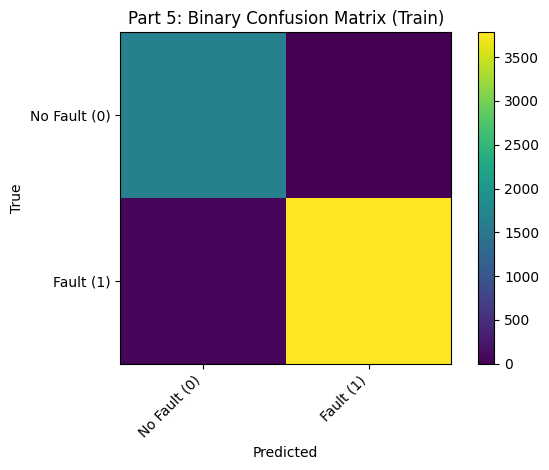


=== Part 5 | Test ===
Accuracy: 0.9902501059771089
Confusion Matrix:
 [[ 710    0]
 [  23 1626]]
              precision    recall  f1-score   support

           0     0.9686    1.0000    0.9841       710
           1     1.0000    0.9861    0.9930      1649

    accuracy                         0.9903      2359
   macro avg     0.9843    0.9930    0.9885      2359
weighted avg     0.9906    0.9903    0.9903      2359



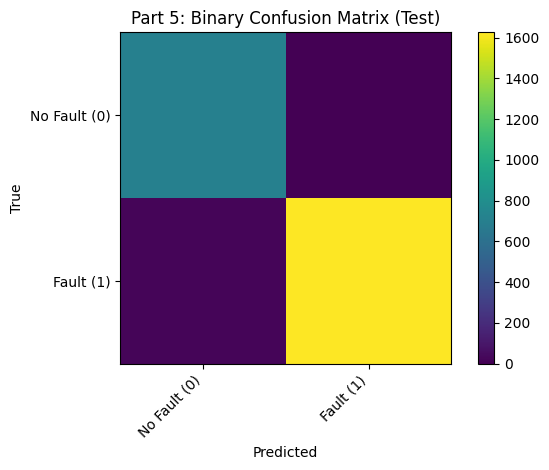

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
binary_labels = ['No Fault (0)', 'Fault (1)']

pred_train, p_train = predict_part5(model, X_train_s5, threshold=0.5)
pred_test,  p_test  = predict_part5(model, X_test_s5,  threshold=0.5)

print("=== Part 5 | Train ===")
print("Accuracy:", accuracy_score(y_train, pred_train))
cm_train = confusion_matrix(y_train, pred_train)
print("Confusion Matrix:\n", cm_train)
print(classification_report(y_train, pred_train, digits=4))
plot_cm(cm_train, 'Part 5: Binary Confusion Matrix (Train)', binary_labels)

print("\n=== Part 5 | Test ===")
print("Accuracy:", accuracy_score(y_test, pred_test))
cm_test = confusion_matrix(y_test, pred_test)
print("Confusion Matrix:\n", cm_test)
print(classification_report(y_test, pred_test, digits=4))
plot_cm(cm_test,  'Part 5: Binary Confusion Matrix (Test)',  binary_labels)